# this generates the AUC plots and score comparisons of tcrdist and tcrbridge of validating and non-validating tcr-pmhc's

figure 4, S4

### imports

In [ ]:
import json
import pandas as pd
import os
import numpy as np
import random
from pathlib import Path
import sys
# from Bio.Data import IUPACData
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay, confusion_matrix
import seaborn as sns


### set parameters

In [ ]:
path_to_labels = 'experiment_set_stats_all-v-1.json'
path_to_scores_file = 'tcr_production_val_nonval_v4/df_alphabridge_pre_msa_tcr_production_val_nonval_v4.csv'
path_to_labels_tetra = 'experiment_set_stats_tetramer_all-v-1.json'

with open('name_color_dict_rebuttal.json', 'r') as f:
    name_color_dict = json.load(f)

In [ ]:
import pandas as pd

labels_all_epitopes = pd.read_json(path_to_labels)
labels_all_epitopes_tetra = pd.read_json(path_to_labels_tetra)
scores_all_epitopes = pd.read_csv(path_to_scores_file)

In [ ]:
from matplotlib import rcParams
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.font_manager as fm 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, rankdata
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, rankdata
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

def set_mpl_params(mpl):
    mylines = 0.75 # pt updated
    mpl.rcParams['axes.linewidth'] = mylines # default 1
    mpl.rcParams['ytick.direction'] = 'out' # default 'in'
    mpl.rcParams['xtick.direction'] = 'out' # default 'in'
    mpl.rcParams['xtick.major.size'] = 3.5 # default 4
    mpl.rcParams['ytick.major.size'] = 3.5 # default 4
    mpl.rcParams['xtick.major.width'] = mylines # default 0.5
    mpl.rcParams['ytick.major.width'] = mylines # default 0.5
    mpl.rcParams['grid.linewidth'] = mylines/1.5# default 0.5
    mpl.rcParams['grid.color'] = '0.8' # default 'k'
    mpl.rcParams['grid.linestyle'] = 'solid'# default ':'
    mpl.rcParams['legend.frameon'] = False # default True
    mpl.rcParams['font.family'] = 'Arial' # added
    mpl.rcParams['figure.dpi']= 300
    mpl.rc("savefig", dpi=300)
    mpl.rcParams['pdf.fonttype'] = 42 # embed fonts as editable text in illustrator
    mpl.rcParams['ps.fonttype'] = 42 # embed fonts as editable text in illustrator
    mpl.rcParams['figure.autolayout'] = True  # set tight layout to always true

    mpl.rcParams['xtick.labelsize'] = 7  # X-axis tick labels
    mpl.rcParams['ytick.labelsize'] = 7  # Y-axis tick labels

    return mpl, mylines

out_path_dropbox = ''
out_path_dropbox_old_labels = ''

SAVE_DROPBOX = True
SAVE_FIGS = True
fm.fontManager.addfont("/Library/Fonts/Arial Unicode.ttf") # local
mpl, mylines = set_mpl_params(mpl)
figsize_prc_auc = (5/2.54, 4/2.54)
dotsize = 12
fontsize_axes = 7

background_alpha = 0.45
color_alpha = 0.6


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

all_aucs = {}
for column_epi in labels_all_epitopes.columns:
    print(column_epi)
    epi_data_subset = labels_all_epitopes[column_epi].T
    pos_ids = epi_data_subset['pos_ids']
    neg_ids = epi_data_subset['neg_ids']
    pos_neg_ids = pos_ids + neg_ids
    subset_pos_neg_ids_scores = scores_all_epitopes[scores_all_epitopes['TCR_name'].str.upper().isin(pos_neg_ids)].copy()
    subset_pos_neg_ids_scores['label'] = subset_pos_neg_ids_scores['TCR_name'].str.upper().apply(lambda x: 1 if x in pos_ids else 0)
    subset_pos_neg_ids_scores['pairwise_ABC'] = (subset_pos_neg_ids_scores['pairwise_score_A_C'] + subset_pos_neg_ids_scores['pairwise_score_B_C'])/2
    subset_pos_neg_ids_scores['ABi_ABC'] = (subset_pos_neg_ids_scores['ABi_score_B_C'] + subset_pos_neg_ids_scores['ABi_score_A_C'])/2
    subset_pos_neg_ids_scores['TCRbridge'] = subset_pos_neg_ids_scores['ABi_ABC']
    subset_pos_neg_ids_scores['TCRbridge_iptmi'] = (subset_pos_neg_ids_scores['iptmi_B_C'] + subset_pos_neg_ids_scores['iptmi_A_C'])/2



    features =[
        'max_PDE', 'max_PMC', 'chain_iptm_A',
       'chain_iptm_B', 'chain_iptm_C', 'chain_iptm_D', 'chain_iptm_E',
       'chain_ptm_A', 'chain_ptm_B', 'chain_ptm_C', 'chain_ptm_D',
       'chain_ptm_E', 'pairwise_score_A_B', 'pairwise_score_A_C',
       'pairwise_score_A_D', 'pairwise_score_B_C', 'pairwise_score_B_D',
       'pairwise_score_C_D', 'ABi_score_A_C', 'ABi_score_B_C', 'ABi_score_A_D',
       'ABi_score_B_D', 'ABi_score_C_D', 'ABi_score_D_E', 'iptmi_A_C',
       'iptmi_B_C', 'iptmi_A_D', 'iptmi_B_D', 'iptmi_C_D', 'iptmi_D_E',
       'ABi_score_A_C_04', 'ABi_score_B_C_04', 'ABi_score_A_D_04',
       'ABi_score_B_D_04', 'ABi_score_C_D_04', 'ABi_score_D_E_04',
       'iptmi_A_C_04', 'iptmi_B_C_04', 'iptmi_A_D_04', 'iptmi_B_D_04',
       'iptmi_C_D_04', 'iptmi_D_E_04', 'contact_iptm', 'AB_score', 'iptm',
       'ptm', 'fraction_disordered', 
       'ranking_score',
       'pairwise_ABC',
        'TCRbridge',
        'TCRbridge_iptmi',
    ]
    y_true = subset_pos_neg_ids_scores['label']
    y_scores = subset_pos_neg_ids_scores[features]
    aucs = {}
    for f in features:
        y_scores = subset_pos_neg_ids_scores[f]
        if y_scores.nunique() > 1:
            aucs[f] = roc_auc_score(y_true, y_scores)
        else:
            aucs[f] = np.nan

    auc_df = pd.DataFrame(list(aucs.items()), columns=['Feature', 'AUC']).dropna()

    auc_df = auc_df.sort_values(by='AUC', ascending=False)
    all_aucs[column_epi] = aucs


GILGFVFTL
LLWNGPMAV
LTDEMIAQY
GLCTLVAML
YLQPRTFLL
TTDPSFLGRY
NLVPMVATV
CINGVCWTV


In [ ]:
mean_all_aucs = {}
for feature in features:
    feature_aucs = [all_aucs[epi][feature] for epi in all_aucs if feature in all_aucs[epi] and not pd.isna(all_aucs[epi][feature])]
    if feature_aucs:
        mean_all_aucs[feature] = np.mean(feature_aucs)
    else:
        mean_all_aucs[feature] = np.nan
mean_all_aucs_df = pd.DataFrame(list(mean_all_aucs.items()), columns=['Feature', 'Mean AUC']).dropna()
mean_all_aucs_df = mean_all_aucs_df.sort_values(by='Mean AUC', ascending=False)
score_order_sorted = mean_all_aucs_df['Feature'].tolist()

mean_all_aucs_df.plot.barh(x='Feature', y='Mean AUC', figsize=(8/2.54, 13/2.54), color='purple', xlim=(0.5, 1.0))


In [ ]:
scores_rename = {'max_PDE': 'max_contact_prob', # alphafold
  'max_PMC': 'max_PMC',# alphafold
  'chain_iptm_A': 'chain_iptm_TCRa', # alphafold
  'chain_iptm_B': 'chain_iptm_TCRb', # alphafold
  'chain_iptm_C': 'chain_iptm_pep', # alphafold
  'chain_iptm_D': 'chain_iptm_MHC', # alphafold
  'chain_iptm_E': 'chain_iptm_B2M', # alphafold
  'chain_ptm_A': 'chain_ptm_TCRa', # alphafold
  'chain_ptm_B': 'chain_ptm_TCRb', # alphafold
  'chain_ptm_C': 'chain_ptm_pep', # alphafold
  'chain_ptm_D': 'chain_ptm_MHC', # alphafold
  'chain_ptm_E': 'chain_ptm_B2M', # alphafold
  'pairwise_score_A_B': 'ABridge_TCRa-TCRb', # alphabridge
  'pairwise_score_A_C': 'ABridge_TCRa-pep', # alphabridge
  'pairwise_score_A_D': 'ABridge_TCRa-MHC', # alphabridge
  'pairwise_score_B_C': 'ABridge_TCRb-pep', # alphabridge
  'pairwise_score_B_D': 'ABridge_TCRb-MHC', # alphabridge
  'pairwise_score_C_D': 'ABridge_pep-MHC', # alphabridge
  'ABi_score_A_C': 'piCS_TCRa-pep', # alphabridge
  'ABi_score_B_C': 'piCS_TCRb-pep', # alphabridge
  'ABi_score_A_D': 'piCS_TCRa-MHC', # alphabridge
  'ABi_score_B_D': 'piCS_TCRb-MHC', # alphabridge
  'ABi_score_C_D': 'piCS_pep-MHC', # alphabridge
  'ABi_score_D_E': 'piCS_MHC-B2M', # alphabridge
  'iptmi_A_C': 'contact_iptm_TCRa-pep', # alphabridge
  'iptmi_B_C': 'contact_iptm_TCRb-pep', # alphabridge
  'iptmi_A_D': 'contact_iptm_TCRa-MHC', # alphabridge
  'iptmi_B_D': 'contact_iptm_TCRb-MHC', # alphabridge
  'iptmi_C_D': 'contact_iptm_pep-MHC', # alphabridge
  'iptmi_D_E': 'contact_iptm_MHC-B2M',  # alphabridge
  'ABi_score_A_C_04': 'piCS_04_TCRa-pep',# TCRbridge ## or "min" instead of 04
  'ABi_score_B_C_04': 'piCS_04_TCRb-pep',# TCRbridge
  'ABi_score_A_D_04': 'piCS_04_TCRa-MHC',# TCRbridge
  'ABi_score_B_D_04': 'piCS_04_TCRb-MHC',# TCRbridge
  'ABi_score_C_D_04': 'piCS_pep-MHC', # TCRbridge
  'ABi_score_D_E_04': 'piCS_MHC-B2M', # TCRbridge
  'iptmi_A_C_04': 'contact_iptm_04_TCRa-pep', # TCRbridge
  'iptmi_B_C_04': 'contact_iptm_04_TCRb-pep', # TCRbridge
  'iptmi_A_D_04': 'contact_iptm_04_TCRa-MHC', # TCRbridge
  'iptmi_B_D_04': 'contact_iptm_04_TCRb-MHC', # TCRbridge
  'iptmi_C_D_04': 'contact_iptm_04_pep-MHC', # TCRbridge
  'iptmi_D_E_04': 'contact_iptm_04_MHC-B2M',  # TCRbridge
  'contact_iptm': 'contact_iptm', # alphafold
  'AB_score': 'piCS_04',#'AB_score', # alphabridge score
  'iptm': 'iptm', # alphafold
  'ptm': 'ptm', # alphafold
  'fraction_disordered': 'fraction_disordered', # alphafold
  'ranking_score': 'ranking_score', # alphafold

  'pairwise_ABC': 'TCRbridge_pairwise', # TCRbridge pairwise
  'TCRbridge': 'TCRbridge', # TCRbridge piCS
  'TCRbridge_iptmi': 'TCRbridge_iptmi', # TCRbridge iptmi
}

/var/folders/k0/ckp_68f90_j5nml0ljfcgfmc81k_s8/T/ipykernel_36945/1579091381.py:26: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([scores_rename.get(label.get_text(), label.get_text()) for label in ax.get_yticklabels()])


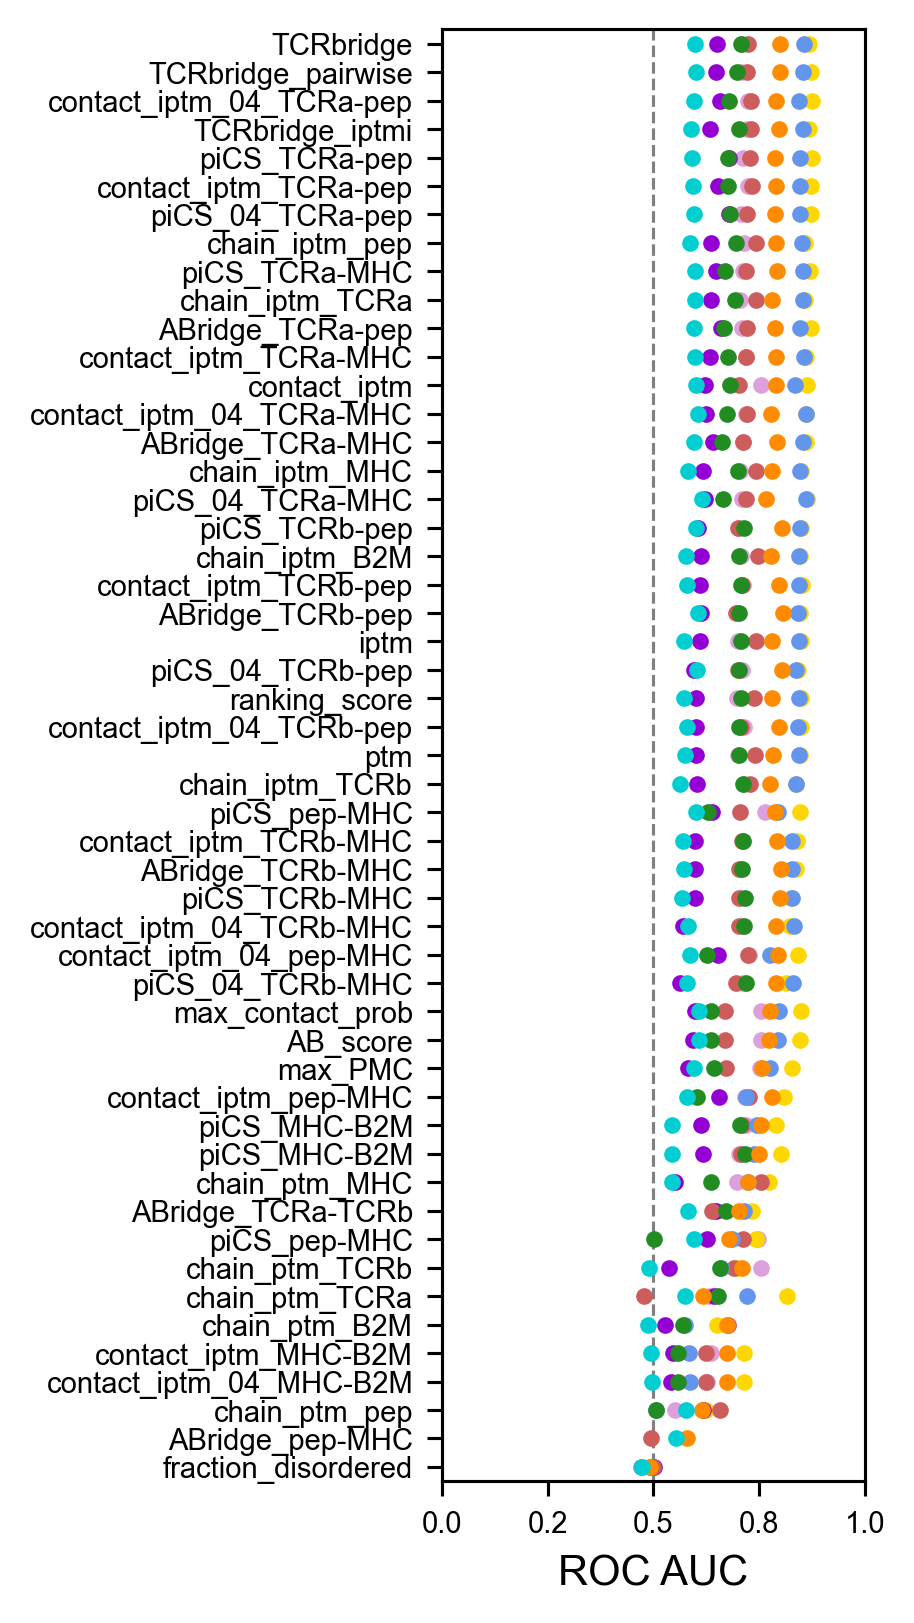

In [ ]:
import matplotlib.patches as mpatches
fig = plt.figure(figsize=(8/2.54, 14/2.54))

for column_epi in all_aucs.keys():
    aucs = all_aucs[column_epi]
    auc_values = list(aucs.values())
    score_names = list(aucs.keys())
    df_boxplot = pd.DataFrame({'Score': score_names, 'AUC': auc_values})
    df_boxplot['Score'] = pd.Categorical(df_boxplot['Score'], categories=score_order_sorted, ordered=True)
    df_boxplot = df_boxplot.sort_values('Score')
    ax = sns.stripplot(x='AUC', y='Score', data=df_boxplot, color=name_color_dict[column_epi], size=4)

ax.set_ylabel('')
ax.set_xlabel('ROC AUC')
all_positions = np.arange(0, 1.05, 0.25)
ax.set_xticks(all_positions)
ax.set_xticklabels([f'{pos:.1f}' for pos in all_positions])
ax.set_yticklabels([scores_rename.get(label.get_text(), label.get_text()) for label in ax.get_yticklabels()])
plt.tight_layout()
plt.axvline(x=0.5, color='grey', linestyle='--', linewidth=0.75)
if SAVE_FIGS:
    plt.savefig(out_path_dropbox + f'compare-metrics_boxplot_all_epitopes-mean.pdf', dpi=300, bbox_inches='tight')

plt.show()
plt.close()

### plot performance using old labels (from preprint v1)

In [ ]:
glc_hits = []
with open('glc_hits_p1e-05', 'r') as f:
    for line in f:
        glc_hits.append(line.strip())

ylq_hits = []
with open('ylq_hits_p1e-05', 'r') as f:
    for line in f:
        ylq_hits.append(line.strip())


In [ ]:
glc_tcr_refs_df = pd.read_csv('glc_tcr_refs_df.csv')
ylq_tcr_refs_df = pd.read_csv('ylq_tcr_refs_df.csv')
ylq_glc_tcrs = pd.read_csv('ylq_glc_screen_deseq2_results_3_replicates.csv')
ylq_tcrs_old = ylq_glc_tcrs[ylq_glc_tcrs['TCR'].str.upper().str.split("_").str[-1] == 'YLQPRTFLL'].copy()
glc_tcrs_old = ylq_glc_tcrs[ylq_glc_tcrs['TCR'].str.upper().str.split("_").str[-1] == 'GLCTLVAML'].copy()

/var/folders/k0/ckp_68f90_j5nml0ljfcgfmc81k_s8/T/ipykernel_69057/69647139.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(out_path_dropbox_old_labels + f'roc_auc_TCRbridge_old_labels_{column_epi}_hits.pdf', dpi=300, bbox_inches='tight')


193 134
0.7804199342271694
421 171
0.8510877192982457
mean roc_auc 0.816 +/- 0.035


/var/folders/k0/ckp_68f90_j5nml0ljfcgfmc81k_s8/T/ipykernel_69057/69647139.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(out_path_dropbox_old_labels + f'roc_auc_TCRbridge_old_labels_{column_epi}_hits.pdf', dpi=300, bbox_inches='tight')


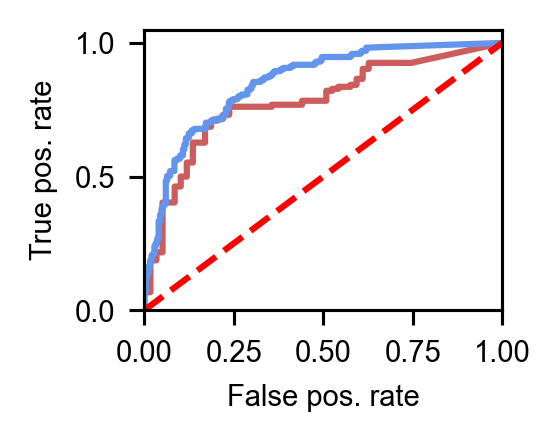

In [ ]:
for score in [
       'ABi_ABC',
       ]:
    plt.figure(figsize=figsize_prc_auc)
    all_scores = []
    for column_epi in labels_all_epitopes.columns:
        if column_epi not in ['YLQPRTFLL', 'GLCTLVAML']:
            continue
        model_name='AF3',
        experiment_name=f'TCRbridge old labels'
        epi_data_subset = labels_all_epitopes[column_epi].T
        pos_ids = glc_hits if column_epi == 'GLCTLVAML' else ylq_hits

        
        scores_df_subset = scores_all_epitopes.copy()
        scores_df_subset['epitope_aa'] = scores_df_subset['TCR_name'].str.split("_").str[-1].str.upper()
        scores_df_subset['TCR_name_upper'] = scores_df_subset['TCR_name'].str.upper()
        if column_epi == 'GLCTLVAML':
            subset_pos_neg_ids_scores = scores_df_subset[scores_df_subset['TCR_name_upper'].isin(glc_tcrs_old['TCR'])].copy()
        else:
            subset_pos_neg_ids_scores = scores_df_subset[scores_df_subset['TCR_name_upper'].isin(ylq_tcrs_old['TCR'])].copy()

        subset_pos_neg_ids_scores['label'] = subset_pos_neg_ids_scores['TCR_name'].str.upper().apply(lambda x: 1 if x in pos_ids else 0)
        print(len(subset_pos_neg_ids_scores), subset_pos_neg_ids_scores['label'].sum())
        subset_pos_neg_ids_scores['pairwise_ABC'] = (subset_pos_neg_ids_scores['pairwise_score_A_C'] + subset_pos_neg_ids_scores['pairwise_score_B_C'])/2
        subset_pos_neg_ids_scores['ABi_ABC'] = (subset_pos_neg_ids_scores['ABi_score_B_C'] + subset_pos_neg_ids_scores['ABi_score_A_C'])/2

        y_true = subset_pos_neg_ids_scores['label']
        y_scores = subset_pos_neg_ids_scores[score]
        precision, recall, _ = precision_recall_curve(y_true, y_scores)
        average_precision = average_precision_score(y_true, y_scores)
        random_baseline = sum(y_true) / len(y_true)
        roc_auc = roc_auc_score(y_true, y_scores)
        print(roc_auc)
        all_scores.append(roc_auc)
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        plt.plot(fpr, tpr, alpha=1, label=f'{column_epi} ({roc_auc:.2f} AUC)', color=name_color_dict[column_epi])

        plt.xlabel('False pos. rate', fontsize=fontsize_axes)
        plt.ylabel('True pos. rate', fontsize=fontsize_axes)
        plt.title(f'{experiment_name} ROC-AUC curve', fontsize=fontsize_axes)
        # plt.grid(True)
        plt.ylim(0, 1.05)
        plt.xlim(0, 1.0)
        plt.legend(loc='lower right', bbox_to_anchor=(2.2, 0.5))
        if SAVE_FIGS:
            plt.savefig(out_path_dropbox_old_labels + f'roc_auc_TCRbridge_old_labels_{column_epi}_hits.pdf', dpi=300, bbox_inches='tight')
        
        # if SAVE_FIGS:
            # plt.savefig(out_path + f'roc_auc_{experiment_name}.pdf', dpi=300, bbox_inches='tight')
            # plt.savefig(out_path + f'roc_auc_{experiment.split("_")[0].upper()}_with_legend_naive.pdf', dpi=300, bbox_inches='tight')
        # tight layout
        # plt.tight_layout()
    print(f'mean roc_auc {np.mean(all_scores):.3f} +/- {np.std(all_scores):.3f}')
    plt.plot([0, 1], [0, 1], color='r', linestyle='--', label=f'Random (0.50 AUC)')
    plt.legend().remove()
    plt.title('')
    if SAVE_FIGS:
        plt.savefig(out_path_dropbox_old_labels + f'roc_auc_TCRbridge_old_labels_glc_ylq_hits.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


### compare to tcrdist

In [ ]:
path_to_tcrdist_scores = 'tcrdist/out'
import glob
import pandas as pd

tcrdist_preds = {}
for csv in glob.glob(path_to_tcrdist_scores + "/*.csv"):
    epitope = csv.split("/")[-1].split("_")[0]
    print(epitope)
    df = pd.read_csv(csv)
    df['label'] = df['name'].str.upper().apply(lambda x: 1 if x in labels_all_epitopes[epitope].T['pos_ids'] else 0)

    print(epitope, len(labels_all_epitopes[epitope].T['pos_ids']), len(labels_all_epitopes[epitope].T['neg_ids']))
    print(df['label'].value_counts(), df.shape)
    tcrdist_preds[epitope] = df.copy()

tcr_dist_preds_orig = tcrdist_preds.copy()

LTDEMIAQY
LTDEMIAQY 75 52
1    75
0    52
Name: label, dtype: int64 (127, 3)
LLWNGPMAV
LLWNGPMAV 162 53
1    162
0     53
Name: label, dtype: int64 (215, 3)
GILGFVFTL
GILGFVFTL 381 199
1    381
0    199
Name: label, dtype: int64 (580, 3)
TTDPSFLGRY
TTDPSFLGRY 170 174
0    174
1    170
Name: label, dtype: int64 (344, 3)
CINGVCWTV
CINGVCWTV 174 54
1    174
0     54
Name: label, dtype: int64 (228, 3)
GLCTLVAML
GLCTLVAML 110 59
1    110
0     59
Name: label, dtype: int64 (169, 3)
YLQPRTFLL
YLQPRTFLL 158 231
0    231
1    158
Name: label, dtype: int64 (389, 3)
NLVPMVATV
NLVPMVATV 91 231
0    231
1     91
Name: label, dtype: int64 (322, 3)


### plot performance comparing tcrdist and tcrbridge

{'tcrdist3': 0.8742597501945422, 'TCRbridge': 0.710455162953877}


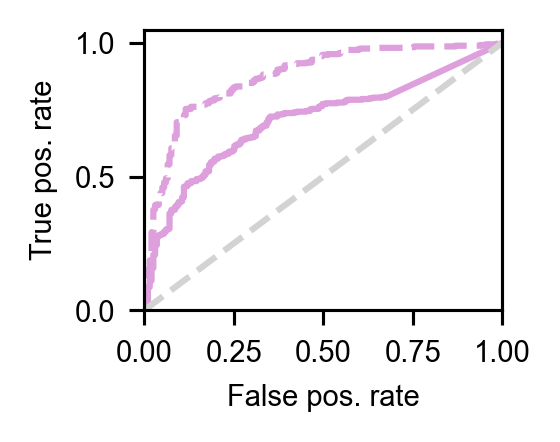

{'tcrdist3': 0.8208711856510598, 'TCRbridge': 0.8688562776613091}


<Figure size 590.551x472.441 with 0 Axes>

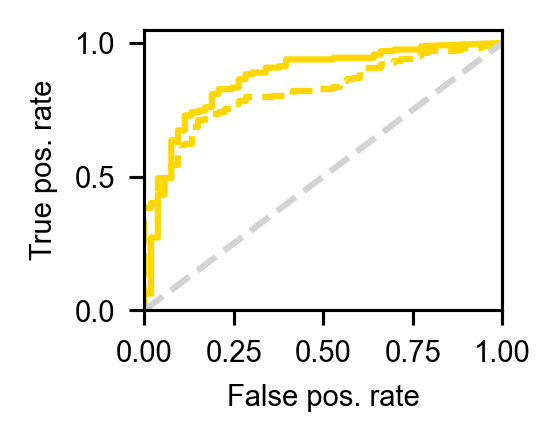

{'tcrdist3': 0.6644871794871795, 'TCRbridge': 0.6494871794871795}


<Figure size 590.551x472.441 with 0 Axes>

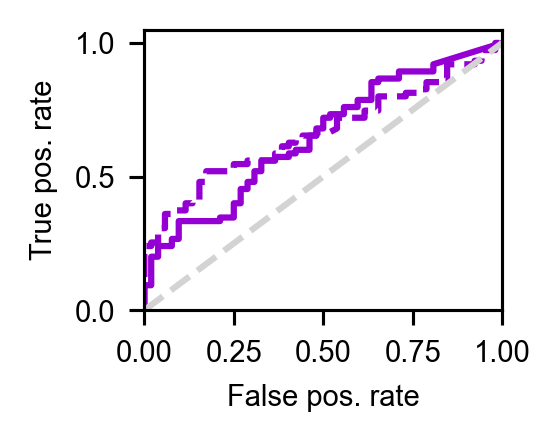

{'tcrdist3': 0.6783513097072419, 'TCRbridge': 0.7243451463790447}


<Figure size 590.551x472.441 with 0 Axes>

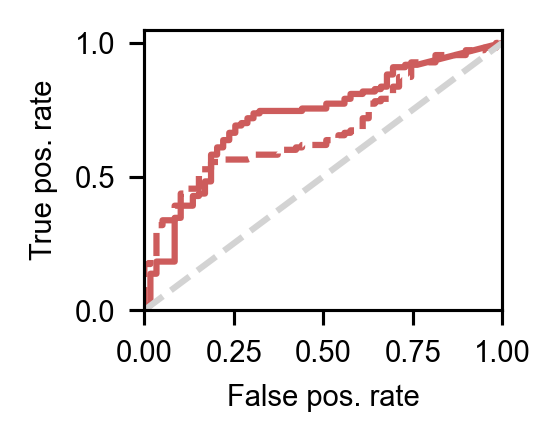

Plotting tetramer labels for GLCTLVAML
{'tcrdist3': 0.7373015873015872, 'TCRbridge': 0.7642682072829132}


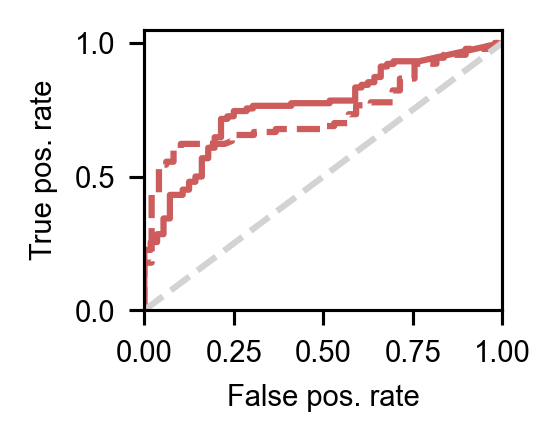

{'tcrdist3': 0.9253931722286153, 'TCRbridge': 0.8561428023453339}


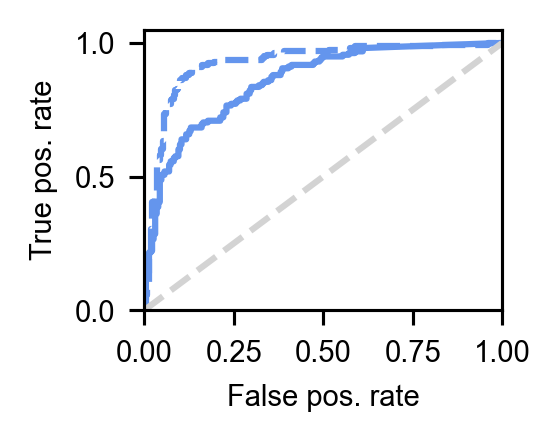

Plotting tetramer labels for YLQPRTFLL
{'tcrdist3': 0.923328760289349, 'TCRbridge': 0.8305071273382438}


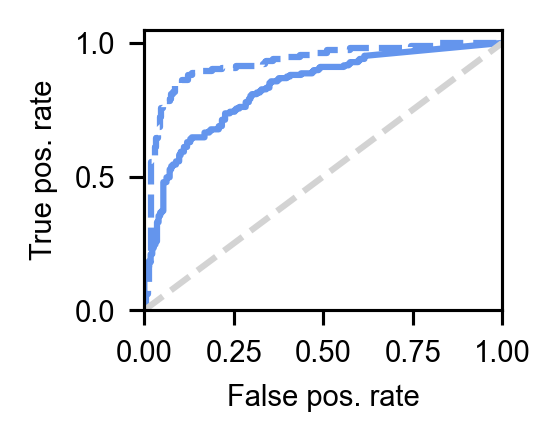

{'tcrdist3': 0.8277214334009466, 'TCRbridge': 0.7083840432724814}


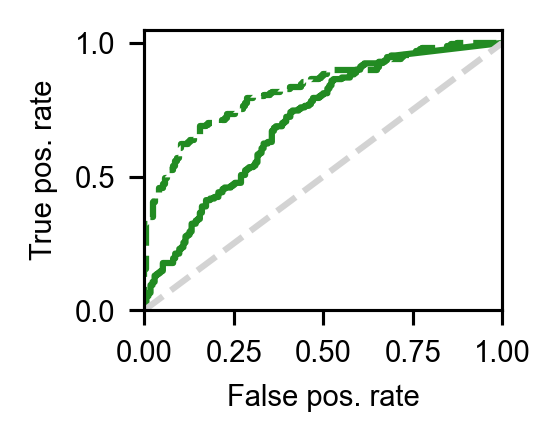

{'tcrdist3': 0.8108558108558109, 'TCRbridge': 0.7998667998667999}


<Figure size 590.551x472.441 with 0 Axes>

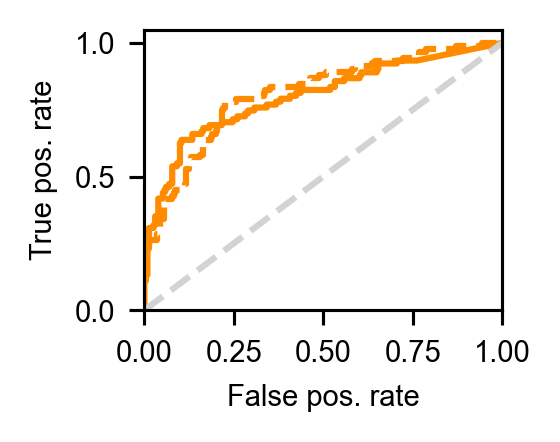

{'tcrdist3': 0.7951255853554704, 'TCRbridge': 0.597914005959983}


<Figure size 590.551x472.441 with 0 Axes>

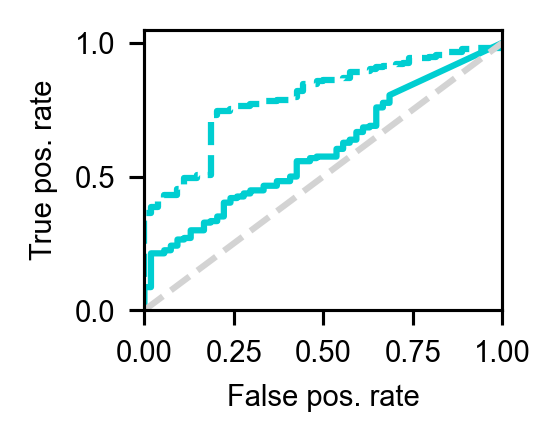

<Figure size 590.551x472.441 with 0 Axes>

In [ ]:

score = "ABi_ABC"
all_scores = []
for column_epi in labels_all_epitopes.columns:

   for label_type, label_dict in zip(['functional','tetramer'], [labels_all_epitopes, labels_all_epitopes_tetra]):
      plt.figure(figsize=figsize_prc_auc)
      roc_auc = {}
      if label_type == 'tetramer' and column_epi not in ['YLQPRTFLL', 'GLCTLVAML']:
         continue
      elif label_type == 'tetramer':
         print(f'Plotting tetramer labels for {column_epi}')
      for model in ['tcrdist3', 'TCRbridge']:
         if model == 'TCRbridge':
            epi_data_subset = label_dict[column_epi].T
            pos_ids = epi_data_subset['pos_ids']
            neg_ids = epi_data_subset['neg_ids']
            pos_neg_ids = pos_ids + neg_ids
            subset_pos_neg_ids_scores = scores_all_epitopes[scores_all_epitopes['TCR_name'].str.upper().isin(pos_neg_ids)].copy()
            # add label by matching on pos_ids and neg_ids
            subset_pos_neg_ids_scores['label'] = subset_pos_neg_ids_scores['TCR_name'].str.upper().apply(lambda x: 1 if x in pos_ids else 0)

            subset_pos_neg_ids_scores['pairwise_ABC'] = (subset_pos_neg_ids_scores['pairwise_score_A_C'] + subset_pos_neg_ids_scores['pairwise_score_B_C'])/2
            subset_pos_neg_ids_scores['ABi_ABC'] = (subset_pos_neg_ids_scores['ABi_score_B_C'] + subset_pos_neg_ids_scores['ABi_score_A_C'])/2


            y_true = subset_pos_neg_ids_scores['label']
            y_scores = subset_pos_neg_ids_scores[score]
            roc_auc[model] = roc_auc_score(y_true, y_scores)
            all_scores.append(roc_auc)
            fpr, tpr, _ = roc_curve(y_true, y_scores)
            plt.plot(fpr, tpr, alpha=1, label=f'{column_epi} ({roc_auc[model]:.2f} AUC)', color=name_color_dict[column_epi])
         elif model == 'tcrdist3':
            subset_df = tcrdist_preds[column_epi].copy()
            labels = label_dict[column_epi].T
            pos_ids = labels['pos_ids']
            neg_ids = labels['neg_ids']
            subset_df = subset_df[subset_df['name'].str.upper().isin(pos_ids + neg_ids)].copy()

            # change label to 1 for pos_ids and 0 for neg_ids within subset_df
            subset_df['label'] = subset_df['name'].str.upper().apply(lambda x: 1 if x in pos_ids else 0)

            y_true = subset_df['label']
            y_scores = -subset_df['prediction']  # invert distance to get score
            roc_auc[model] = roc_auc_score(y_true, y_scores)
            fpr, tpr, _ = roc_curve(y_true, y_scores)
            plt.plot(fpr, tpr, alpha=1, label=f'{column_epi} TCRdist3 ({roc_auc[model]:.2f} AUC)', color=name_color_dict[column_epi], linestyle='--')

      plt.xlabel('False pos. rate', fontsize=fontsize_axes)
      plt.ylabel('True pos. rate', fontsize=fontsize_axes)

      plt.ylim(0, 1.05)
      plt.xlim(0, 1.0)

      print(roc_auc)
      plt.plot([0, 1], [0, 1], color='lightgrey', linestyle='--', label=f'Random (0.50 AUC)')

      if label_type == 'functional':
         plt.savefig(out_path_dropbox + 
                     f"roc_auc_{column_epi}_tcrdist3_{roc_auc['tcrdist3']:.2f}_TCRbridge_{roc_auc['TCRbridge']:.2f}.pdf", 
                     dpi=300, 
                     bbox_inches='tight')
      elif label_type == 'tetramer':
         plt.savefig(out_path_dropbox_old_labels + 
                     f"roc_auc_{column_epi}_{label_type}_tcrdist3_{roc_auc['tcrdist3']:.2f}_TCRbridge_{roc_auc['TCRbridge']:.2f}_tetra.pdf", 
                     dpi=300, 
                     bbox_inches='tight')


      plt.show()
      plt.close()


#### Plot using labels from the tetramer screens separately

In [ ]:

tetramer_labels = pd.read_json(path_to_labels_tetra)

GLCTLVAML
102 pos 56 neg 158 total
YLQPRTFLL
167 pos 226 neg 393 total
mean roc_auc 0.797 +/- 0.033


/Users/b.kwee/miniconda3/envs/mlenv_update/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


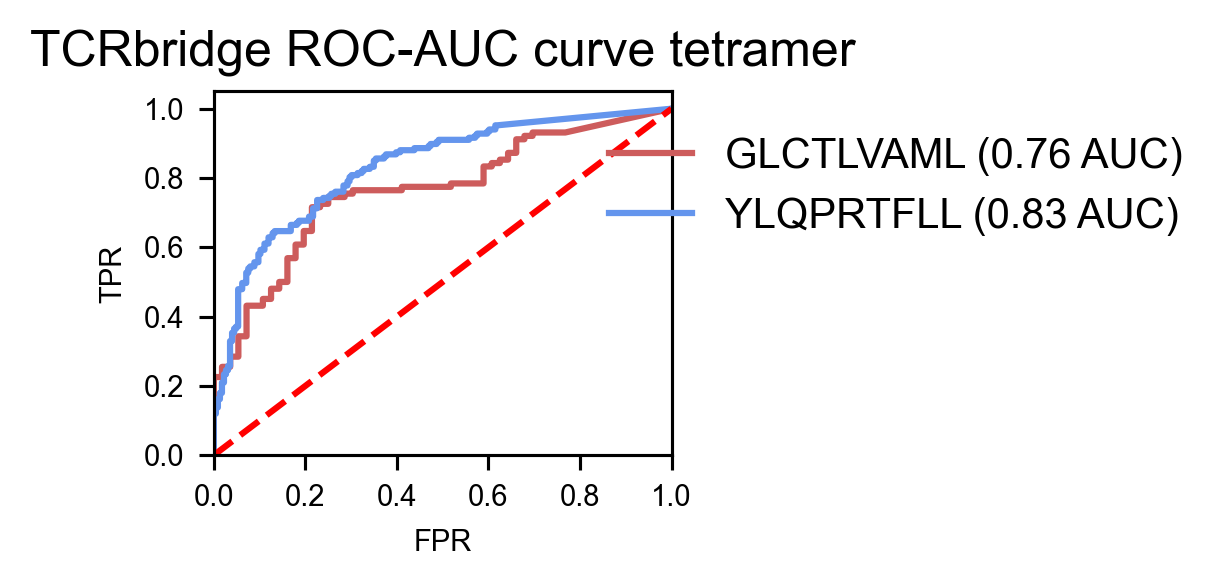

In [ ]:
for score in [
       'ABi_ABC',
       ]:
   plt.figure(figsize=figsize_prc_auc)
   all_scores = []
   for column_epi in tetramer_labels.columns:
      print(column_epi)
      model_name='AF3',
      experiment_name='TCRbridge'
      # print(column_epi)
      epi_data_subset = tetramer_labels[column_epi].T
      pos_ids = epi_data_subset['pos_ids']
      neg_ids = epi_data_subset['neg_ids']
      pos_neg_ids = pos_ids + neg_ids
      print(len(pos_ids), "pos", len(neg_ids), "neg", len(pos_neg_ids), "total")
      subset_pos_neg_ids_scores = scores_all_epitopes[scores_all_epitopes['TCR_name'].str.upper().isin(pos_neg_ids)].copy()
      # add label by matching on pos_ids and neg_ids
      subset_pos_neg_ids_scores['label'] = subset_pos_neg_ids_scores['TCR_name'].str.upper().apply(lambda x: 1 if x in pos_ids else 0)

      subset_pos_neg_ids_scores['pairwise_ABC'] = (subset_pos_neg_ids_scores['pairwise_score_A_C'] + subset_pos_neg_ids_scores['pairwise_score_B_C'])/2
      subset_pos_neg_ids_scores['ABi_ABC'] = (subset_pos_neg_ids_scores['ABi_score_B_C'] + subset_pos_neg_ids_scores['ABi_score_A_C'])/2

      y_true = subset_pos_neg_ids_scores['label']
      y_scores = subset_pos_neg_ids_scores[score]
      precision, recall, _ = precision_recall_curve(y_true, y_scores)
      average_precision = average_precision_score(y_true, y_scores)
      random_baseline = sum(y_true) / len(y_true)
      roc_auc = roc_auc_score(y_true, y_scores)
      # print(f'roc_auc {roc_auc:.3f}')
      all_scores.append(roc_auc)
      fpr, tpr, _ = roc_curve(y_true, y_scores)
      plt.plot(fpr, tpr, alpha=1, label=f'{column_epi} ({roc_auc:.2f} AUC)', color=name_color_dict[column_epi])

      plt.xlabel('FPR', fontsize=fontsize_axes)
      plt.ylabel('TPR', fontsize=fontsize_axes)
      plt.title(f'{experiment_name} ROC-AUC curve tetramer')
      # plt.grid(True)
      plt.ylim(0, 1.05)
      plt.xlim(0, 1.0)
      plt.legend(loc='lower right', bbox_to_anchor=(2.2, 0.5))

      # if SAVE_FIGS:
         # plt.savefig(out_path + f'roc_auc_{experiment_name}.pdf', dpi=300, bbox_inches='tight')
         # plt.savefig(out_path + f'roc_auc_{experiment.split("_")[0].upper()}_with_legend_naive.pdf', dpi=300, bbox_inches='tight')
      # tight layout
      # plt.tight_layout()
   print(f'mean roc_auc {np.mean(all_scores):.3f} +/- {np.std(all_scores):.3f}')
   plt.plot([0, 1], [0, 1], color='r', linestyle='--', label=f'Random (0.50 AUC)')

   plt.show()
   plt.close()


### plot scores of tcrdist and tcrbridge of validating and non-validating separately

In [ ]:
import matplotlib.colors as mcolors

def lighten_color(color, amount=0.3):
    """
    Lightens the given color by mixing it with white.
    amount=0 means no change, amount=1 means fully white.
    """
    try:
        c = mcolors.to_rgb(color)
    except ValueError:
        return color  # fallback if color name invalid
    return mcolors.to_hex([1 - (1 - x) * (1 - amount) for x in c])

name_color_dict_light = {k: lighten_color(v, 0.5) for k, v in name_color_dict.items()}

<Figure size 590.551x472.441 with 0 Axes>

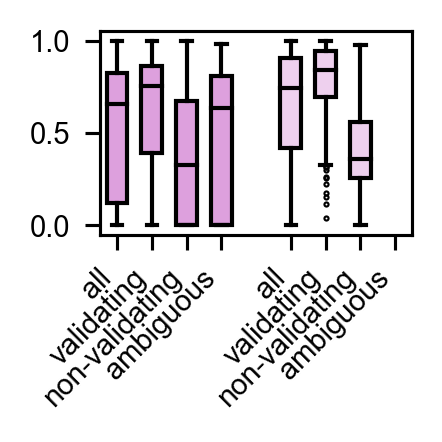

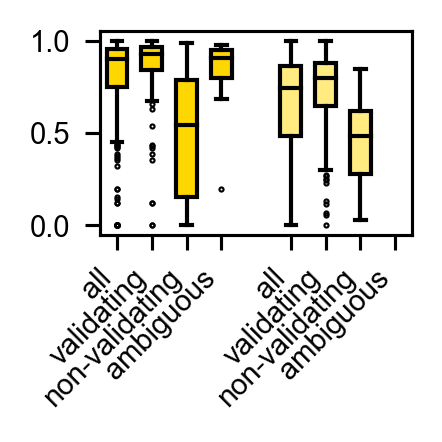

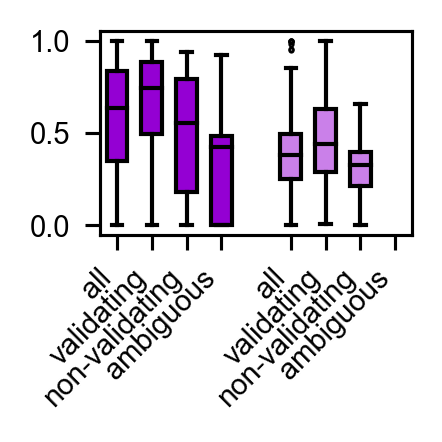

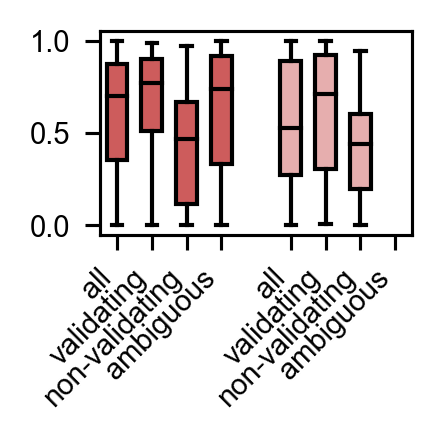

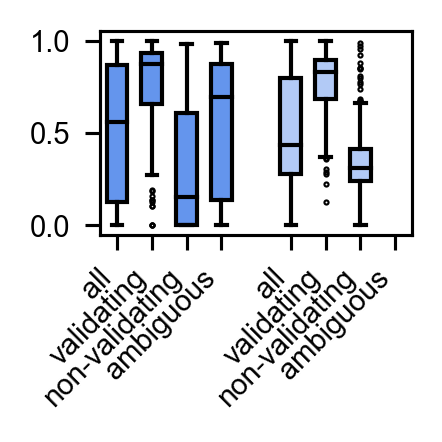

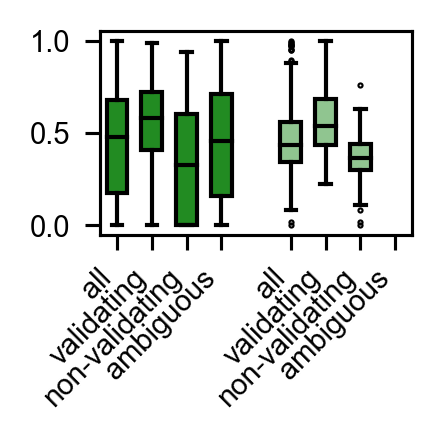

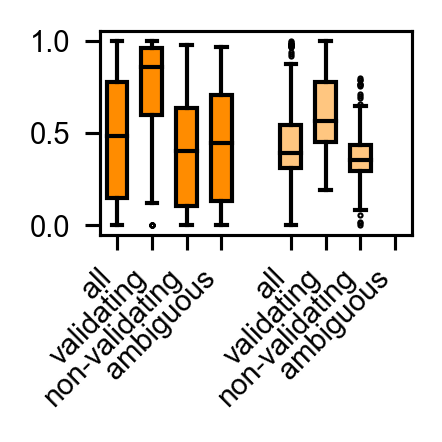

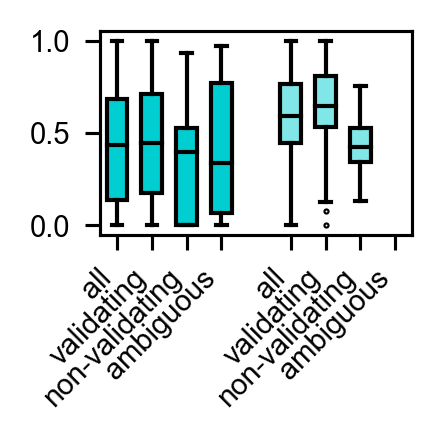

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
from sklearn.preprocessing import MinMaxScaler
import matplotlib.patches as mpatches

for score in [
       'ABi_ABC',
       ]:
    plt.figure(figsize=figsize_prc_auc)
    all_scores = []
    for column_epi in labels_all_epitopes.columns:
        epi_data_subset = labels_all_epitopes[column_epi].T
        pos_ids = epi_data_subset['pos_ids']
        ambig_ids = epi_data_subset['ambiguous_ids'] 
        intersection_ids = epi_data_subset['intersection_ids']
        neg_ids = epi_data_subset['neg_ids']
        
        pos_neg_ids = pos_ids + neg_ids + ambig_ids + intersection_ids


        experiment_name='TCRbridge'
        subset_pos_neg_ids_scores = scores_all_epitopes[scores_all_epitopes['TCR_name'].str.upper().isin(pos_neg_ids)].copy()
        subset_pos_neg_ids_scores['label'] = subset_pos_neg_ids_scores['TCR_name'].str.upper().apply(
            lambda x: 1 if x in pos_ids 
            else 2 if x in ambig_ids
            else 3 if x in intersection_ids
            else 0
        )
        subset_pos_neg_ids_scores['ABi_ABC'] = (subset_pos_neg_ids_scores['ABi_score_B_C'] + subset_pos_neg_ids_scores['ABi_score_A_C'])/2
        y_scores_af3 = subset_pos_neg_ids_scores[score].copy()
        y_scores_af3 = y_scores_af3.fillna(0)

        scaler_AF3 = MinMaxScaler(feature_range=(0, 1))
        y_scores_af3_norm = scaler_AF3.fit_transform(y_scores_af3.values.reshape(-1, 1)).flatten()
        subset_pos_neg_ids_scores['AF3-ABi_norm'] = y_scores_af3_norm


        # 'tcrdist3':
        subset_df_tcr_dist = tcr_dist_preds_orig[column_epi].copy()
        subset_df_tcr_dist = subset_df_tcr_dist[subset_df_tcr_dist['name'].str.upper().isin(pos_neg_ids)].copy()
        subset_df_tcr_dist['label'] = subset_df_tcr_dist['name'].str.upper().apply(
            lambda x: 1 if x in pos_ids 
            else 2 if x in ambig_ids
            else 3 if x in intersection_ids
            else 0
        )


        y_scores_tcrdist = -subset_df_tcr_dist['prediction']  # invert distance to get score
        y_scores_tcrdist = y_scores_tcrdist.fillna(0)

        scaler_tcrdist = MinMaxScaler(feature_range=(0, 1))
        y_scores_tcrdist_norm = scaler_tcrdist.fit_transform(y_scores_tcrdist.values.reshape(-1, 1)).flatten()
        subset_df_tcr_dist['tcrdist3_norm'] = y_scores_tcrdist_norm

        figsize_boxplot = (4/2.54, 4/2.54)

      

        # Define categories
        categories = ['all', 'validating', 'non-validating', 'ambiguous']

        # Prepare data
        data_AF3 = {
            'all': subset_pos_neg_ids_scores['AF3-ABi_norm'],
            'validating': subset_pos_neg_ids_scores[subset_pos_neg_ids_scores['label'] == 1]['AF3-ABi_norm'],
            'non-validating': subset_pos_neg_ids_scores[subset_pos_neg_ids_scores['label'] == 0]['AF3-ABi_norm'],
            'ambiguous': list(subset_pos_neg_ids_scores[subset_pos_neg_ids_scores['label'] == 2]['AF3-ABi_norm']) + list(subset_pos_neg_ids_scores[subset_pos_neg_ids_scores['label'] == 3]['AF3-ABi_norm'])
        }
        data_tcrdist = {
            'all': subset_df_tcr_dist['tcrdist3_norm'],
            'validating': subset_df_tcr_dist[subset_df_tcr_dist['label'] == 1]['tcrdist3_norm'],
            'non-validating': subset_df_tcr_dist[subset_df_tcr_dist['label'] == 0]['tcrdist3_norm'],    
            'ambiguous': list(subset_df_tcr_dist[subset_df_tcr_dist['label'] == 2]['tcrdist3_norm']) + list(subset_df_tcr_dist[subset_df_tcr_dist['label'] == 3]['tcrdist3_norm'])
        }


        flierprops = dict(marker='.', 
                        markersize=1,
                        linestyle='none'
                        )

        fig, ax = plt.subplots(figsize=(figsize_boxplot))
        positions_af3 = [1, 2, 3, 4,]
        positions_tcrdist = [6, 7, 8, 9]
        bp_AF3 = ax.boxplot([data_AF3[cat] for cat in categories],
                            sym='.',
                            positions=positions_af3,
                            widths=0.6,
                            patch_artist=True,
                            medianprops=dict(color="black"),
                            boxprops=dict(edgecolor="black", facecolor=name_color_dict[column_epi]),
                            flierprops=flierprops
                            )
        bp_tcrdist = ax.boxplot([data_tcrdist[cat] for cat in categories],
                            sym='.',
                            positions=positions_tcrdist,
                            widths=0.6,
                            patch_artist=True,
                            medianprops=dict(color="black"),
                            boxprops=dict(edgecolor="black", facecolor=name_color_dict_light[column_epi]),
                            flierprops=flierprops
                            )
    
        all_positions = positions_af3 + positions_tcrdist
        all_labels = categories + categories

        ax.set_xticks(all_positions)
        ax.set_xticklabels(all_labels, rotation=45, ha='right')  

        ax.set_xticks(all_positions)
        af3_patch = mpatches.Patch(color=name_color_dict[column_epi], label='TCRbridge')
        tcrdist_patch = mpatches.Patch(color=name_color_dict_light[column_epi], label='tcrdist3')
        if SAVE_FIGS:
            plt.savefig(out_path_dropbox + f'boxplot_{column_epi}_AF3-tcrdist.pdf', dpi=300, bbox_inches='tight')
        plt.tight_layout()
        plt.show()
        plt.close()